# Student Placement Prediction Modelling

## Project Objective:
This Project utilizes Machine Learning practices with the aim at Predicting Students placement based on their performance.
The project dissects deepers into academic and behavioral factors such as:
- Study Hours
- Attendance Percentage
- Sleep Hours
- Internet Usage
- Assignments Completed
- Previous Scores
- Exam Score.

So as to determine Students Placement Success at University level.

## Setting up the Environment for Data Pre-Processing and Analysis:
- Done by importing all the Necessary Libraries and Packages to be used

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib 
%matplotlib inline
import matplotlib.pyplot as plt
import plotly as px 

## For Statistics and Machine Learning:
We shall be installing specific library packages to enable further analysis. These include:
- Scipy and Stats Models for Statistics.
- Scikit Learn for advanced statistics and Machine Learning

In [2]:
!pip install scipy --quiet
!pip install statsmodels --quiet
%pip install scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


## Loading, Reading and Storing the data:
- We shall be saving our dataset into a dataframe called students

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
students = pd.read_csv(r"C:\Users\Gifton\Videos\0.0002 DATA ANALYTICS\103_MACHINE_LEARNING\PROJECT_B (LOGISTIC_REG)\student_dataset_10000_rows.csv")
students.sample(3)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
3943,5,87,5,1,5,83,100.00,Placed
7168,10,84,7,4,16,62,100.00,Placed
1050,4,71,7,9,10,37,62.55,Not Placed


## Understanding the structure of the data:
- Allows to understand the dataset further, check for abnomalies like duplicates and missing values to assist in Data Cleaning procedures

In [5]:
def quality_check(students):
    info_report ={
        'shape':students.shape,
        'total records': len(students),
        'missing_records':students.isnull().sum(),
        'duplicate_records':students.duplicated().sum()
    }
    return info_report
info_report = quality_check(students)
print(info_report)

{'shape': (10000, 8), 'total records': 10000, 'missing_records': study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64, 'duplicate_records': np.int64(0)}


# Data types Check?
- Understanding data types enables accurate representation of each data value in its columns.

In [6]:
students.dtypes

study_hours                int64
attendance                 int64
sleep_hours                int64
internet_usage             int64
assignments_completed      int64
previous_score             int64
exam_score               float64
placement_status          object
dtype: object

## Distribution of the Variables?
- How are each of the variables distributed? First we define Numerical VS Categorical variables.

In [7]:
numerical_cols = students.select_dtypes(include=['int64'])
numerical_cols.tail(2)                                 

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score
9998,10,75,7,5,8,52
9999,2,70,6,11,16,52


In [8]:
categorical_cols = students.select_dtypes(include=['object'])
categorical_cols.head(2)

,placement_status
0,Placed
1,Placed


## Summary Statistics Computations.
- Summary Statistics computations allows us to understand how the dataset is distributed and spread

In [9]:
numeric_stats = numerical_cols.describe()
numeric_stats

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000


In [10]:
category_stats = categorical_cols.describe()
category_stats

,placement_status
count,10000
unique,2
top,Placed
freq,8356


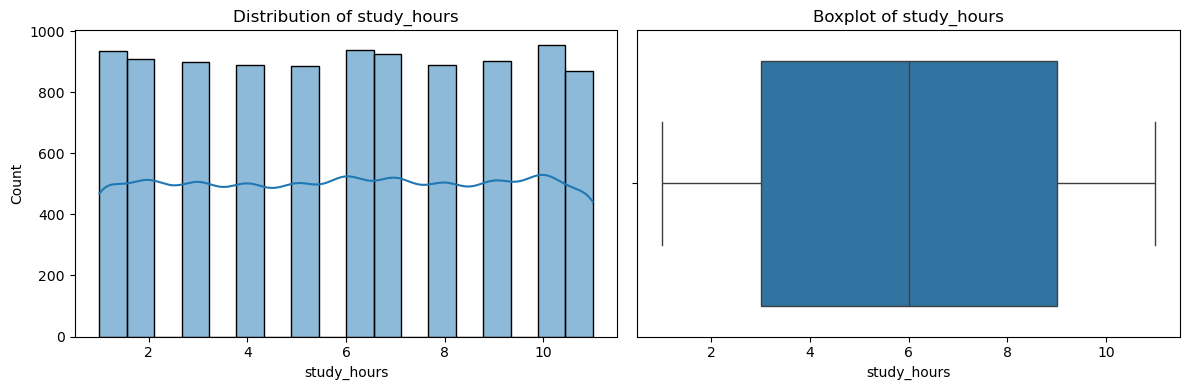

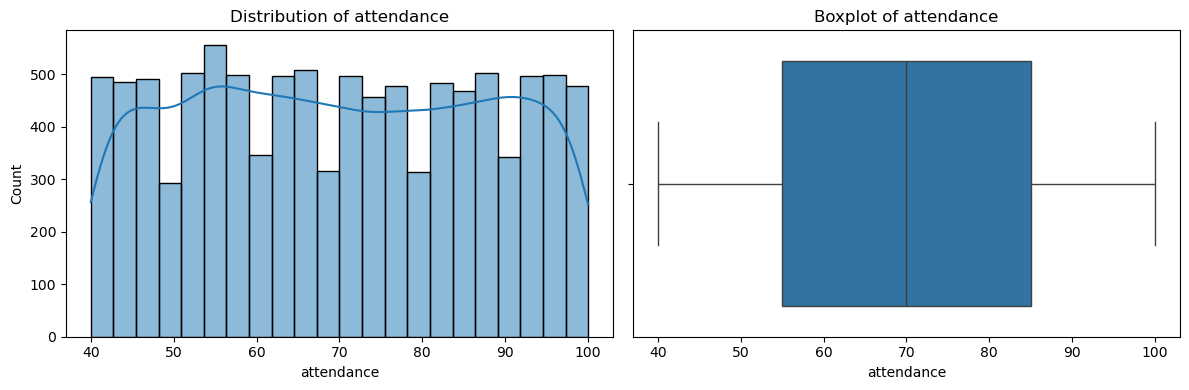

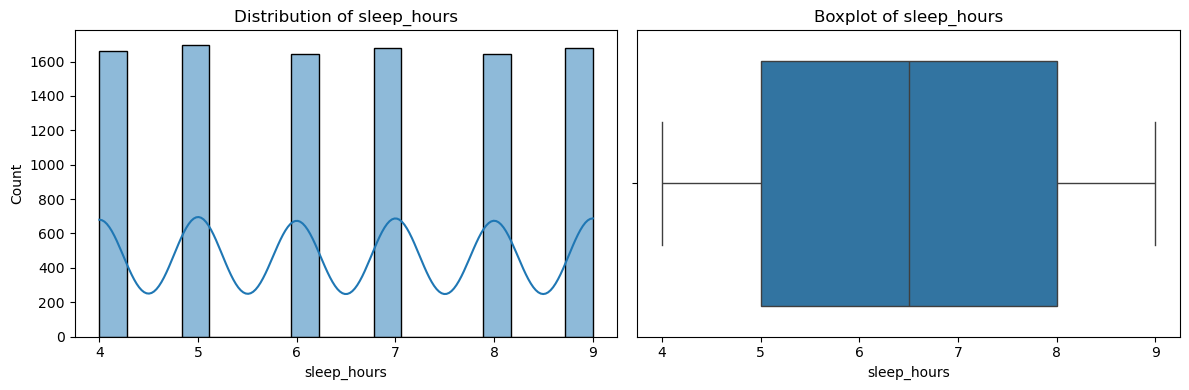

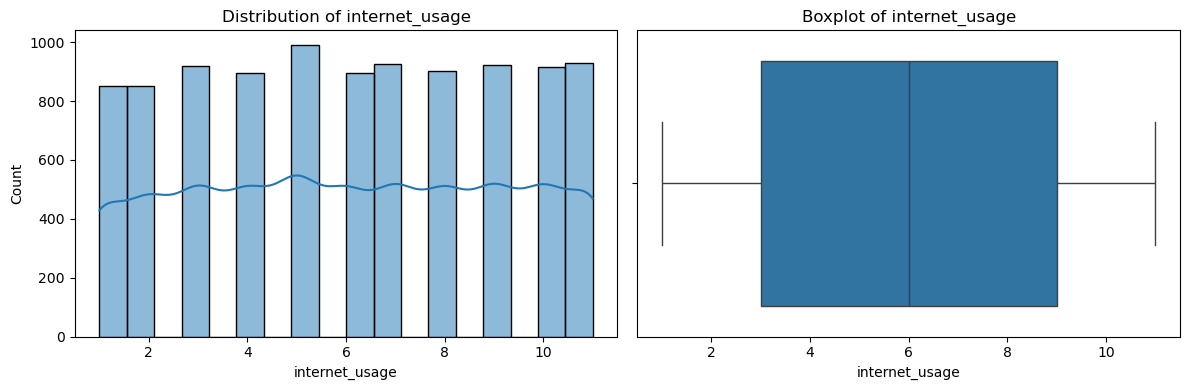

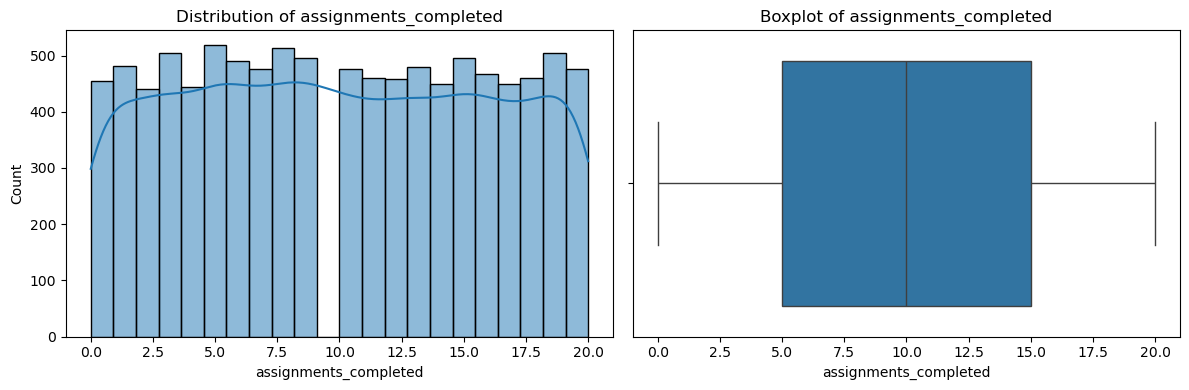

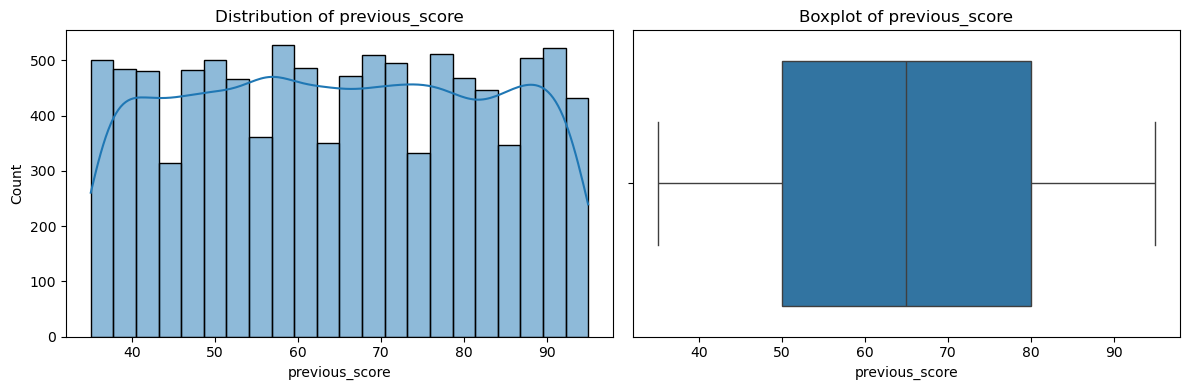

In [11]:
## Patterns and Distributions?
## For numerical cols:
for col in numerical_cols:
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    sns.histplot(students[col],kde=True,ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    sns.boxplot(x=students[col],ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

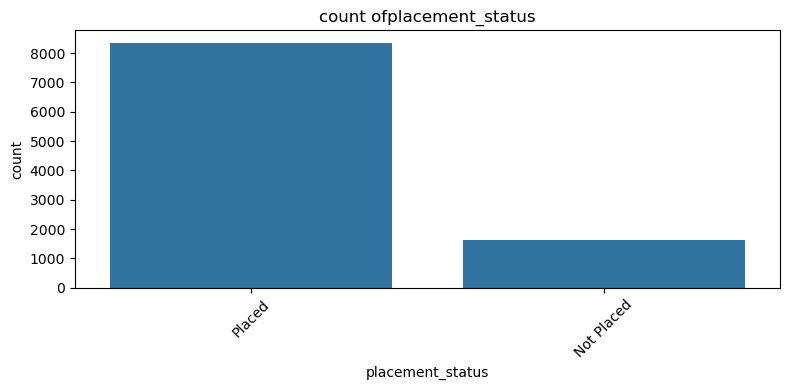

In [12]:
## For Categorical column distribution:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=students, x=col,order=students[col].value_counts().index)
    plt.title(f"count of{col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Statistics Computation:
- Since we have a data of 10,000 students, we will apply Sampling Procedures on the Entire population.
- Sampling will allow to make inference on the Larger data.
- We'll simulate a Sample of 2500 students With Replacement
- .

In [13]:
## Importing the Necessary Libraries:
from scipy import stats
import statsmodels.api as sm

In [14]:
students['placement_status'].unique()

array(['Placed', 'Not Placed'], dtype=object)

## MODEL BUILDING:
- In this phase, we shall build a Logistic Model to Classify Students Placement Based on Academic and Behavioral Factors.
- The Target Variable (Variable to be Predicted == [Placement Status])
- The Predictor Variables include == [study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score]

In [15]:
students['placement_status'].unique()

array(['Placed', 'Not Placed'], dtype=object)

In [16]:
placement_encoded = {
    'Not Placed':0,
    'Placed':1
}
students['placement_encoded'] =students['placement_status'].map(placement_encoded)

In [17]:
students.head(2)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status,placement_encoded
0,7,56,8,7,10,62,100.0,Placed,1
1,4,69,5,3,8,56,100.0,Placed,1


In [18]:
## Define the X and Y variables:
x = students[['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score']]
y = students['placement_status']

In [19]:
## Import Modules and Classes for Logistic Regression Model Building.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [20]:
## Dividing the Data into TRAIN_TEST_SPLIT:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=42)

## Feature Scaling:
- Allows us to work with data values in the same range of values

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)  # Learns and transforms
x_test_scaled = scaler.transform(x_test)         # Only transforms (don't fit again!)


In [41]:
clf = LogisticRegression(max_iter=10000)  # max_iter prevents convergence warnings
clf = LogisticRegression().fit(x_train_scaled, y_train)

## Your model is now trained!

In [42]:
## Build on the LogisticRegression:
clf = LogisticRegression().fit(x_train_scaled,y_train)

In [43]:
## Obtain the Coefficients and Intercepts values:
clf.coef_

array([[ 0.34468721,  0.26550974,  0.04731191, -0.09773666,  0.28535085,
         0.18045926, 12.25294704]])

In [44]:
clf.intercept_

array([14.14842768])

In [45]:
## Save on the Model Predictions:
y_pred = clf.predict(x_test)

C:\Users\Gifton\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [46]:
clf.predict(x_test)

C:\Users\Gifton\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


array(['Placed', 'Placed', 'Placed', ..., 'Placed', 'Placed', 'Placed'],
      shape=(3000,), dtype=object)

In [47]:
y_pred = clf.predict(x_test)

C:\Users\Gifton\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [48]:
# Print out the predicted probabilities
clf.predict_proba(x_test)[::,-1]


C:\Users\Gifton\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


array([1., 1., 1., ..., 1., 1., 1.], shape=(3000,))

## CONFUSION MATRIX
- Used to evaluate how accurate our model is at predicting.

In [50]:
# Import the metrics module from scikit-learn 
import sklearn.metrics as metrics


In [51]:
# Calculate the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred, labels = clf.classes_)

In [52]:
# Create the confusion matrix as a visualization 
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_) 

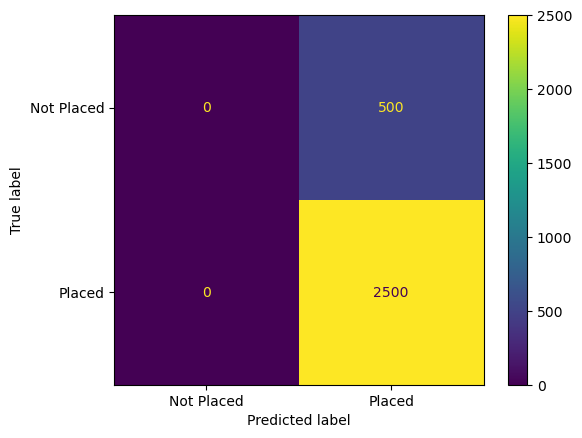

In [53]:
# Display the confusion matrix
disp.plot()


In [54]:
print(f"Training samples: {len(x_train)}")
print(f"Testing samples: {len(x_test)}")

Training samples: 7000
Testing samples: 3000


## Building the Model:
- We now actually start to build on the Model


In [9]:
df.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')

In [64]:
## Make Predictions
y_pred = model.predict(x_test_scaled)


In [65]:
## Get probabilities too (useful later)
y_prob = model.predict_proba(x_test_scaled)


In [67]:
## Evaluate the Model
## Accuracy (percentage of correct predictions):

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
## Confusion Matrix (shows where it got confused):


NameError: name 'accuracy_score' is not defined